In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from xgboost import XGBClassifier


In [2]:
df = pd.read_csv("hypertension.csv")
print(df.columns)


Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'hypertension',
       'Sleep_Duration'],
      dtype='object')


In [3]:
# ===============================
# STEP 1: Add Environmental Features
# ===============================

import numpy as np

# Simulate new features (if real data not available)

np.random.seed(42)

# PM2.5 pollution level (5 to 150 µg/m³)
df["Pollution_PM25"] = np.random.normal(60, 20, len(df)).clip(5,150)

# Walkability score (0 to 100)
df["Walkability"] = np.random.uniform(20, 90, len(df))

# Average daily steps (1000 to 15000)
df["AvgSteps"] = np.random.normal(6000, 2500, len(df)).clip(1000,15000)

In [4]:
df["age"]=df["age"]

In [5]:
df["height_m"] = df["height"] / 100
df["BMI"] = df["weight"] / (df["height_m"] ** 2)


In [6]:
# ===============================
# STEP 2: Update Feature Columns
# ===============================

features = [
    "age",
    "gender",
    "BMI",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "Sleep_Duration",
    "Pollution_PM25",
    "Walkability",
    "AvgSteps"
]

X = df[features]
y = df["hypertension"]   # your target column
print(X.columns)
print(y.value_counts())


Index(['age', 'gender', 'BMI', 'cholesterol', 'gluc', 'smoke', 'alco',
       'active', 'Sleep_Duration', 'Pollution_PM25', 'Walkability',
       'AvgSteps'],
      dtype='object')
hypertension
0    27842
1    27738
Name: count, dtype: int64


In [7]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,hypertension,Sleep_Duration,Pollution_PM25,Walkability,AvgSteps,height_m,BMI
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,6.4,69.934283,69.215351,5815.605806,1.68,21.967120
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,5.4,57.234714,65.299768,9017.423682,1.56,34.927679
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,7.1,72.953771,65.474299,8955.145674,1.65,23.507805
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,4.2,90.460597,78.142211,4925.117687,1.69,28.710479
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,5.8,55.316933,67.187393,1000.000000,1.56,23.011177


In [8]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)


X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

log_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
xgb_model = XGBClassifier(eval_metric='logloss')

log_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

log_pred = log_model.predict_proba(X_test_scaled)[:,1]
rf_pred = rf_model.predict_proba(X_test)[:,1]
xgb_pred = xgb_model.predict_proba(X_test)[:,1]

hybrid_pred = 0.3*log_pred + 0.3*rf_pred + 0.4*xgb_pred
hybrid_class = (hybrid_pred > 0.5).astype(int)

print("Hybrid Accuracy:", accuracy_score(y_test, hybrid_class))
print("Hybrid ROC-AUC:", roc_auc_score(y_test, hybrid_pred))
print(classification_report(y_test, hybrid_class))


Hybrid Accuracy: 0.6393104067522672
Hybrid ROC-AUC: 0.6897775445763853
              precision    recall  f1-score   support

           0       0.63      0.66      0.65      5555
           1       0.65      0.62      0.63      5582

    accuracy                           0.64     11137
   macro avg       0.64      0.64      0.64     11137
weighted avg       0.64      0.64      0.64     11137



In [10]:
print(y_resampled.value_counts())

hypertension
0    27842
1    27842
Name: count, dtype: int64


In [11]:
# ===============================
# STEP 5: Updated Risk Calculator
# ===============================

def calculate_hypertension_risk(user_input):

    user_scaled = scaler.transform(user_input)

    log_p = log_model.predict_proba(user_scaled)[:,1]
    rf_p = rf_model.predict_proba(user_input)[:,1]
    xgb_p = xgb_model.predict_proba(user_input)[:,1]

    final_score = (log_p + rf_p + xgb_p) / 3
    risk_percent = final_score[0] * 100

    if risk_percent < 30:
        level = "Low Risk"
    elif risk_percent < 60:
        level = "Moderate Risk"
    else:
        level = "High Risk"

    return round(risk_percent,2), level


In [12]:
def digital_twin_simulation(user_data, years=5):

    results = []
    current_data = user_data.copy()

    for year in range(1, years + 1):

        # Access single row using .loc
        current_data.loc[0, "AvgSteps"] = min(
            current_data.loc[0, "AvgSteps"] + 1000, 20000
        )

        current_data.loc[0, "Walkability"] = min(
            current_data.loc[0, "Walkability"] + 5, 100
        )

        current_data.loc[0, "Pollution_PM25"] = max(
            current_data.loc[0, "Pollution_PM25"] - 5, 5
        )

        current_data.loc[0, "Sleep_Duration"] = min(
            current_data.loc[0, "Sleep_Duration"] + 0.3, 9
        )

        score, level = calculate_hypertension_risk(current_data)

        results.append({
            "Year": year,
            "RiskScore": score,
            "RiskLevel": level
        })

    return pd.DataFrame(results)

In [13]:
user_input = pd.DataFrame([{
    "age": 55,
    "gender": 1,
    "BMI": 31,
    "cholesterol": 3,
    "gluc": 2,
    "smoke": 1,
    "alco": 0,
    "active": 0,
    "Sleep_Duration": 5,
    "Pollution_PM25": 85,
    "Walkability": 35,
    "AvgSteps": 3500
}])

score, level = calculate_hypertension_risk(user_input)

print("Hypertension Risk Score:", score, "%")
print("Risk Level:", level)
projection = digital_twin_simulation(user_input, years=5)

print(projection)


Hypertension Risk Score: 47.1 %
Risk Level: Moderate Risk
   Year  RiskScore      RiskLevel
0     1      45.32  Moderate Risk
1     2      38.74  Moderate Risk
2     3      46.42  Moderate Risk
3     4      44.25  Moderate Risk
4     5      44.55  Moderate Risk


C:\Users\munja\AppData\Local\Temp\ipykernel_33336\2256380717.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.3' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  current_data.loc[0, "Sleep_Duration"] = min(


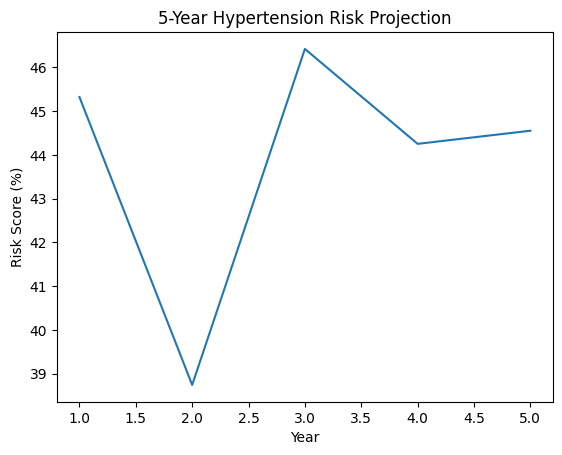

In [14]:
import matplotlib.pyplot as plt

plt.plot(projection["Year"], projection["RiskScore"])
plt.xlabel("Year")
plt.ylabel("Risk Score (%)")
plt.title("5-Year Hypertension Risk Projection")
plt.show()

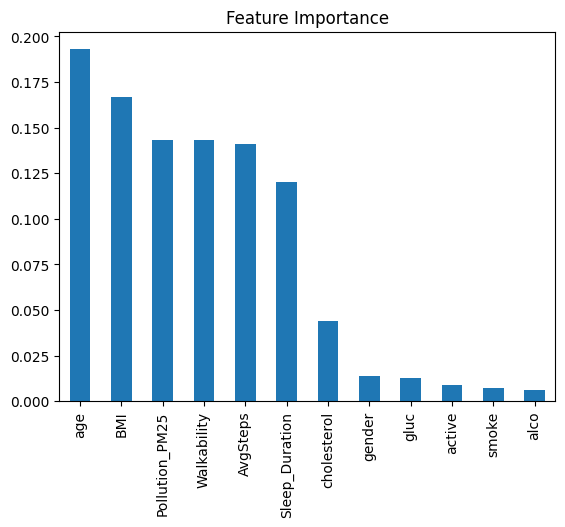

In [15]:
import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=features)
importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance")
plt.show()

In [16]:
import joblib
import os
joblib.dump(rf_model, "hypertension_rf.pkl")
joblib.dump(log_model, "hypertension_log.pkl")
joblib.dump(xgb_model, "hypertension_xgb.pkl")

['hypertension_xgb.pkl']

In [17]:
import joblib
import os

# IMPORTANT: Save feature names
feature_list = X.columns.tolist()

hypertension_bundle = {
    "lr": log_model,
    "rf": rf_model,
    "xgb": xgb_model,
    "scaler": scaler,          # ✅ include scaler
    "features": feature_list   # ✅ include feature list
}

os.makedirs("models", exist_ok=True)

save_path = os.path.join("models", "hypertension.pkl")
joblib.dump(hypertension_bundle, save_path)

print(f"Hypertension model bundle saved successfully at {save_path}")

Hypertension model bundle saved successfully at models\hypertension.pkl


In [18]:
print("Training Complete ✅")
print("Number of Features:", len(features))

Training Complete ✅
Number of Features: 12
